# Yahoo Finance data and technical analysis

## Overview
This notebook downloads historical stock market data, computes technical indicators, constructs prediction targets, performs data cleaning, and produces the final market dataset.

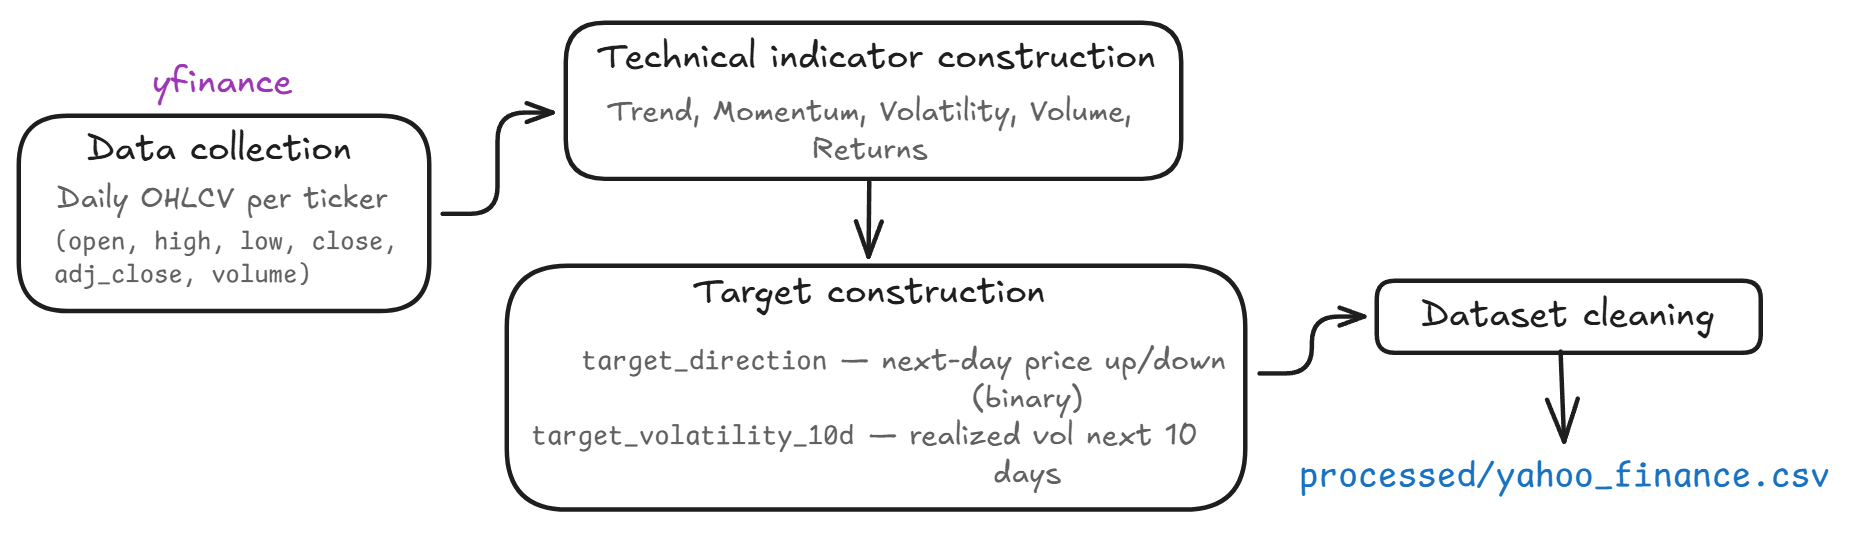

## 1. Configuration

In [11]:
import os
import yfinance as yf
import pandas as pd
import numpy as np
import mlflow
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import scipy.stats as stats


TICKERS    = ["NVDA", "AMD", "INTC"]
START_DATE = "2016-03-31"
END_DATE = "2026-04-14"

OUTPUT_DIR = "datasets/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. Data collection

Daily stock market data were downloaded from Yahoo Finance for NVIDIA (NVDA), AMD, and Intel (INTC) using the `yfinance` Python library. For each company, the dataset includes the opening price (`open`), highest price (`high`), lowest price (`low`), closing price (`close`), adjusted closing price (`adj_close`), and trading volume (`volume`).


In [12]:
def download_price_data(tickers: list[str], start: str, end: str) -> pd.DataFrame:
    """
    Download daily OHLCV data from Yahoo Finance for multiple tickers.

    Args:
        tickers : List of ticker symbols.
        start   : Start date string (YYYY-MM-DD).
        end     : End date string (YYYY-MM-DD).

    Returns:
        DataFrame with columns: date, ticker, open, high, low,
        close, adj_close, volume.
    """
    all_data = []

    for ticker in tickers:
        print(f"Downloading {ticker}...")
        raw = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)

        if raw.empty:
            print(f"  No data returned for {ticker}.")
            continue

        raw = raw.reset_index()
        raw.columns = [col[0].lower() if isinstance(col, tuple) else col.lower()
                       for col in raw.columns]

        raw = raw.rename(columns={"adj close": "adj_close"})
        raw["ticker"] = ticker
        raw["date"]   = pd.to_datetime(raw["date"]).dt.date

        all_data.append(raw[["date", "ticker", "open", "high", "low",
                              "close", "adj_close", "volume"]])
        print(f"  {len(raw)} trading days downloaded.")

    df = pd.concat(all_data, ignore_index=True)
    df = df.sort_values(["ticker", "date"]).reset_index(drop=True)
    return df


df_prices = download_price_data(TICKERS, START_DATE, END_DATE)

print(f"\nTotal rows : {len(df_prices)}")
print(f"Date range : {df_prices['date'].min()} to {df_prices['date'].max()}")
df_prices.head()

  2523 trading days downloaded.
  2523 trading days downloaded.
  2523 trading days downloaded.

Total rows : 7569
Date range : 2016-03-31 to 2026-04-13


,date,ticker,open,high,low,close,adj_close,volume
0,2016-03-31,AMD,2.84,2.88,2.80,2.85,2.85,9071500
1,2016-04-01,AMD,2.79,2.88,2.76,2.83,2.83,8257700
2,2016-04-04,AMD,2.83,2.87,2.80,2.83,2.83,5591100
3,2016-04-05,AMD,2.76,2.84,2.72,2.76,2.76,9640200
4,2016-04-06,AMD,2.75,2.80,2.72,2.80,2.80,12534600


## 3. Technical indicator construction

To enrich the raw market data with additional information about price behavior, a set of technical indicators was computed for each company. The selected indicators can be grouped into six categories: trend, momentum, volatility, volume, returns, and price-based indicators.

Trend indicators describe the overall direction of price movement, momentum indicators capture the speed and strength of price changes, volatility indicators measure market variability and risk, volume indicators reflect trading activity, while return- and price-based indicators provide additional information about recent market dynamics. All indicators were calculated separately for each company using adjusted closing prices in order to maintain consistency across the historical time series.

The selection of indicators was based on previous studies in stock market prediction and financial time-series forecasting, with references provided alongside each implemented indicator.

In [13]:
def compute_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute technical indicators for a single ticker DataFrame
    sorted chronologically.

    Indicators computed:
        Trend       : SMA10, SMA20 (Botunac et al., 2020; Qolipour et al., 2021)
                      WMA10 (Botunac et al., 2020)
        Momentum    : RSI14 (Khaidem et al., 2016; Botunac et al., 2020)
                      MACD, MACD signal
                          (Khaidem et al., 2016; Botunac et al., 2020; Alsubaie et al., 2019)
                      Stochastic %K and %D (Khaidem et al., 2016; Botunac et al., 2020)
                      Williams %R (Khaidem et al., 2016; Botunac et al., 2020)
                      ROC10 (Khaidem et al., 2016; Alsubaie et al., 2019)
                      Momentum/MOM (Botunac et al., 2020; Alsubaie et al., 2019)
                      TRIX (Alsubaie et al., 2019)
        Volatility  : Bollinger Bands upper/middle/lower
                          (Chaudhari & Mahajan, 2025; Alsubaie et al., 2019, Qolipour et al., 2021)
                      ATR14 (Wilder, 1978; Alsubaie et al., 2019)
                      NATR (Alsubaie et al., 2019)
                      Historical Volatility 20 (Tsay, 2005, Ch. 3.15)
                      STD20 (Alsubaie et al., 2019)
        Volume      : OBV (Granville, 1963; Khaidem et al., 2016; Alsubaie et al., 2019)
                      AD -- Chaikin A/D Line (Alsubaie et al., 2019)
                      ADOsc -- Chaikin A/D Oscillator (Alsubaie et al., 2019)
                      Log Volume, Volume Change (Li et al., 2014)
        Returns     : Log return (Tsay, 2005, Ch. 1.1)
                      Lagged returns 1d, 2d, 5d (Tsay, 2005, Ch. 2.2)
        Price       : High/Low ratio (Li et al., 2014)
        HAR         : (Heterogeneous Autoregressive) Volatility Features(Corsi, F. (2009))
    """
    d = df.copy().reset_index(drop=True)
    close  = d["adj_close"]
    high   = d["high"]
    low    = d["low"]
    volume = d["volume"]

    # ------------------------------------------------------------------
    # Trend -- SMA
    # Reference: Botunac, I., Panjkota, A., & Matetic, M. (2020).
    #            The Effect of Feature Selection on the Performance of
    #            LSTM Neural Network in Stock Market Predictions.
    #            DAAAM International Symposium.
    #            Qolipour, F., Ghasemzadeh, M., & Mohammad-Karimi, N.
    #            (2021). The Predictability of Tree-based Machine Learning
    #            Algorithms in the Big Data Context. IJE, 34(1), 82-89.
    # ------------------------------------------------------------------
    for w in [10, 20]:
        d[f"sma_{w}"] = close.rolling(w).mean()

    # ------------------------------------------------------------------
    # Trend -- WMA (Weighted Moving Average)
    # Reference: Botunac et al. (2020)
    # ------------------------------------------------------------------
    def wma(series, length):
        weights = np.arange(1, length + 1)
        return series.rolling(length).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)

    d["wma_10"] = wma(close, 10)

    # ------------------------------------------------------------------
    # Momentum -- RSI
    # Reference: Khaidem et al. (2016).
    #            Botunac et al. (2020).
    # ------------------------------------------------------------------
    delta       = close.diff()
    gain        = delta.clip(lower=0).rolling(14).mean()
    loss        = (-delta.clip(upper=0)).rolling(14).mean()
    rs          = gain / loss.replace(0, np.nan)
    d["rsi_14"] = 100 - (100 / (1 + rs))

    # ------------------------------------------------------------------
    # Momentum -- MACD + Signal Line + Histogram
    # Reference: Khaidem et al. (2016).
    #            Botunac et al. (2020).
    #            Alsubaie, Y., El Hindi, K., & Alsalman, H. (2019).
    #            Cost-Sensitive Prediction of Stock Price Direction.
    #            IEEE Access.
    # ------------------------------------------------------------------
    ema12            = close.ewm(span=12, adjust=False).mean()
    ema26            = close.ewm(span=26, adjust=False).mean()
    d["macd"]        = ema12 - ema26
    d["macd_signal"] = d["macd"].ewm(span=9, adjust=False).mean()
    
    # ------------------------------------------------------------------
    # Momentum -- Stochastic Oscillator (%K and %D)
    # Reference: Khaidem et al. (2016).
    #            Botunac et al. (2020).
    # ------------------------------------------------------------------
    low14        = low.rolling(14).min()
    high14       = high.rolling(14).max()
    d["stoch_k"] = 100 * (close - low14) / (high14 - low14).replace(0, np.nan)
    d["stoch_d"] = d["stoch_k"].rolling(3).mean()

    # ------------------------------------------------------------------
    # Momentum -- Williams %R
    # Reference: Khaidem et al. (2016).
    #            Botunac et al. (2020).
    # ------------------------------------------------------------------
    d["williams_r"] = -100 * (high14 - close) / (high14 - low14).replace(0, np.nan)

    # ------------------------------------------------------------------
    # Momentum -- Price Rate of Change (ROC)
    # Reference: Khaidem et al. (2016).
    #            Alsubaie et al. (2019).
    # ------------------------------------------------------------------
    d["roc_10"] = close.pct_change(10) * 100

    # ------------------------------------------------------------------
    # Momentum -- Momentum (MOM)
    # Reference: Botunac et al. (2020).
    #            Alsubaie et al. (2019).
    # ------------------------------------------------------------------
    d["mom_10"] = close.diff(10)

    
    # ------------------------------------------------------------------
    # Momentum -- TRIX (1-day ROC of Triple Smooth EMA)
    # Reference: Alsubaie et al. (2019).
    # ------------------------------------------------------------------
    def trix(series, length):
        ema1 = series.ewm(span=length, adjust=False).mean()
        ema2 = ema1.ewm(span=length, adjust=False).mean()
        ema3 = ema2.ewm(span=length, adjust=False).mean()
        return ema3.pct_change() * 100

    d["trix"] = trix(close, 15)

    # ------------------------------------------------------------------
    # Volatility -- Bollinger Bands
    # Reference: Chaudhari, A.Y., & Mahajan, S. (2025). Prediction of
    #            stock market using sentiment analysis and ensemble
    #            learning. MethodsX, 14.
    #            Alsubaie et al. (2019).
    #            Qolipour et al., 2021.
    # ------------------------------------------------------------------
    sma20          = close.rolling(20).mean()
    std20          = close.rolling(20).std()
    d["bb_upper"]  = sma20 + 2 * std20
    d["bb_middle"] = sma20
    d["bb_lower"]  = sma20 - 2 * std20
    
    # ------------------------------------------------------------------
    # Volatility -- ATR (Average True Range)
    # Reference: Alsubaie et al. (2019).
    # ------------------------------------------------------------------
    prev_close  = close.shift(1)
    tr = pd.concat([
          high - low,
          (high - prev_close).abs(),
          (low  - prev_close).abs()
          ], axis=1).max(axis=1)
    d["atr_14"] = tr.rolling(14).mean()

    # ------------------------------------------------------------------
    # Volatility -- NATR (Normalized Average True Range)
    # Reference: Alsubaie et al. (2019).
    # ------------------------------------------------------------------
    d["natr"] = (d["atr_14"] / close.replace(0, np.nan)) * 100

    # ------------------------------------------------------------------
    # Volatility -- Historical Volatility (annualized, 20-day window)
    # Reference: Tsay, R.S. (2005). Analysis of Financial Time Series,
    #            Ch. 3.15. (2nd ed.).
    # ------------------------------------------------------------------
    log_ret          = np.log(close / close.shift(1))
    d["hist_vol_20"] = log_ret.rolling(20).std() * np.sqrt(252) * 100

    # ------------------------------------------------------------------
    # Volatility -- STD (Standard Deviation of close, 20-day)
    # Reference: Alsubaie et al. (2019).
    # ------------------------------------------------------------------
    d["std_20"] = close.rolling(20).std()

    # ------------------------------------------------------------------
    # Volume -- OBV (On Balance Volume)
    # Reference: Khaidem et al. (2016).
    #            Alsubaie et al. (2019).
    # ------------------------------------------------------------------
    obv = [0]
    for i in range(1, len(d)):
        if close.iloc[i] > close.iloc[i - 1]:
            obv.append(obv[-1] + volume.iloc[i])
        elif close.iloc[i] < close.iloc[i - 1]:
            obv.append(obv[-1] - volume.iloc[i])
        else:
            obv.append(obv[-1])
    d["obv"] = obv

    # ------------------------------------------------------------------
    # Volume -- AD (Chaikin Accumulation/Distribution Line)
    # Reference: Alsubaie et al. (2019).
    # ------------------------------------------------------------------
    clv      = ((close - low) - (high - close)) / (high - low).replace(0, np.nan)
    ad       = (clv * volume).cumsum()
    d["ad"]  = ad

    # ------------------------------------------------------------------
    # Volume -- ADOsc (Chaikin A/D Oscillator)
    # Reference: Alsubaie et al. (2019).
    # ------------------------------------------------------------------
    d["adosc"] = ad.ewm(span=3, adjust=False).mean() - ad.ewm(span=10, adjust=False).mean()

    # ------------------------------------------------------------------
    # Volume -- Log Volume and Volume Change
    # Reference: Li, H., Yang, Z., & Li, T. (2014). Algorithmic Trading
    #            Strategy Based On Massive Data Mining. Stanford
    #            University. Formulas (5) and (6).
    # ------------------------------------------------------------------
    d["log_volume"]  = np.log(volume)
    d["volume_chng"] = np.log(volume / volume.shift(1))

    # ------------------------------------------------------------------
    # Returns -- Log return and lagged returns
    # Reference: Tsay, R.S. (2005). Analysis of Financial Time Series.
    #            Ch. 1.1 (log return), Ch. 2.2 (lagged returns).
    # ------------------------------------------------------------------
    d["log_return"] = log_ret
    d["return_1d"]  = close.pct_change(1) * 100
    d["return_2d"]  = close.pct_change(2) * 100
    d["return_5d"]  = close.pct_change(5) * 100

    # ------------------------------------------------------------------
    # Price -- High/Low ratio
    # Reference: Li et al. (2014). Formula (4).
    # ------------------------------------------------------------------
    d["hl_ratio"] = high / low

    # ------------------------------------------------------------------
    # HAR (Heterogeneous Autoregressive) Volatility Features
    # Reference: Corsi, F. (2009). A Simple Approximate Long-Memory
    #            Model of Realized Volatility. Journal of Financial
    #            Econometrics, 7(2), 174-196.
    # ------------------------------------------------------------------
    # HAR model uses lagged realized volatility at daily, weekly and
    # monthly horizons as primary predictors of future volatility.
    # These are the most important features for volatility forecasting.
    log_ret_sq       = log_ret ** 2
    d["rv_daily"]   = np.sqrt(log_ret_sq.shift(1)) * np.sqrt(252) * 100
    d["rv_weekly"]  = np.sqrt(log_ret_sq.shift(1).rolling(5).mean()) * np.sqrt(252) * 100
    d["rv_monthly"] = np.sqrt(log_ret_sq.shift(1).rolling(22).mean()) * np.sqrt(252) * 100

    # Lagged hist_vol_20 — additional volatility persistence features
    d["hv_lag_1"]  = d["hist_vol_20"].shift(1)
    d["hv_lag_5"]  = d["hist_vol_20"].shift(1).rolling(5).mean()
    d["hv_lag_22"] = d["hist_vol_20"].shift(1).rolling(22).mean()

    return d


# Apply per ticker
results = []
for ticker in TICKERS:
    subset = df_prices[df_prices["ticker"] == ticker].copy()
    subset = compute_indicators(subset)
    results.append(subset)

df_indicators = pd.concat(results, ignore_index=True)

print(f"Columns : {len(df_indicators.columns)}")
print(f"Rows    : {len(df_indicators)}")
df_indicators.head()

Columns : 43
Rows    : 7569


,date,ticker,open,high,low,close,adj_close,volume,sma_10,sma_20,...,return_1d,return_2d,return_5d,hl_ratio,rv_daily,rv_weekly,rv_monthly,hv_lag_1,hv_lag_5,hv_lag_22
0,2016-03-31,NVDA,0.89800,0.90000,0.88375,0.89075,0.872227,379884000,NaN,NaN,...,NaN,NaN,NaN,1.018388,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-04-01,NVDA,0.88525,0.90425,0.87850,0.90375,0.884956,348292000,NaN,NaN,...,1.459442,NaN,NaN,1.029311,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-04-04,NVDA,0.91125,0.91600,0.89150,0.89500,0.876388,393940000,NaN,NaN,...,-0.968182,0.477130,NaN,1.027482,23.000494,NaN,NaN,NaN,NaN,NaN
3,2016-04-05,NVDA,0.88700,0.90200,0.88350,0.89375,0.875164,339568000,NaN,NaN,...,-0.139648,-1.106478,NaN,1.020939,15.444301,NaN,NaN,NaN,NaN,NaN
4,2016-04-06,NVDA,0.88250,0.89550,0.86575,0.89500,0.876388,453376000,NaN,NaN,...,0.139844,0.000000,NaN,1.034363,2.218399,NaN,NaN,NaN,NaN,NaN


## 4. Target construction

Two prediction targets were constructed to capture different aspects of future stock market behavior.

The first target, `target_direction`, is a binary classification variable indicating whether the adjusted closing price on the next trading day is higher than the current day's adjusted closing price. A value of 1 represents an increase in price, while a value of 0 represents a decrease or no change.

The second target, `target_volatility_10d`, represents the realized volatility over the subsequent ten trading days. It is calculated as the annualized standard deviation of future daily logarithmic returns and serves as a measure of future market uncertainty and risk.

Together, these targets enable the evaluation of whether public sentiment contributes not only to predicting the direction of future price movements but also to forecasting future market volatility.

In [ ]:
def add_targets(df: pd.DataFrame, volatility_window: int = 10) -> pd.DataFrame:
    """
    Add prediction targets per ticker.

    target_direction:
        1 if next-day close > today's close, otherwise 0.

    target_volatility_10d:
        Realized volatility over the next 10 trading days,
        computed as the annualized standard deviation of
        future daily log returns.
    """
    df = df.copy()

    # Direction target
    next_day_close = df.groupby("ticker")["adj_close"].shift(-1)

    df["target_direction"] = (
        next_day_close > df["adj_close"]
    ).astype(int)

    # Daily log returns
    log_returns = (
        df.groupby("ticker")["adj_close"]
          .transform(lambda x: np.log(x / x.shift(1)))
    )

    # Future realized volatility
    df["target_volatility_10d"] = (
        log_returns.groupby(df["ticker"])
        .transform(
            lambda x:
            x.shift(-1)
             .rolling(volatility_window)
             .std()
             .shift(-(volatility_window - 1))
        )
        * np.sqrt(252)
        * 100
    )

    
    return df


df_final = add_targets(df_indicators)

In [16]:
df_final.columns

Index(['date', 'ticker', 'open', 'high', 'low', 'close', 'adj_close', 'volume',
       'sma_10', 'sma_20', 'wma_10', 'rsi_14', 'macd', 'macd_signal',
       'stoch_k', 'stoch_d', 'williams_r', 'roc_10', 'mom_10', 'trix',
       'bb_upper', 'bb_middle', 'bb_lower', 'atr_14', 'natr', 'hist_vol_20',
       'std_20', 'obv', 'ad', 'adosc', 'log_volume', 'volume_chng',
       'log_return', 'return_1d', 'return_2d', 'return_5d', 'hl_ratio',
       'rv_daily', 'rv_weekly', 'rv_monthly', 'hv_lag_1', 'hv_lag_5',
       'hv_lag_22', 'target_direction', 'target_volatility_10d',
       'target_volume_ratio'],
      dtype='object')

In [17]:
print(f"\nShape: {df_final.shape}")


Shape: (7569, 46)


## 5. Dataset cleaning

The missing values observed in the dataset are expected and arise from the construction of both technical indicators and prediction target. Many technical indicators rely on rolling windows of previous observations (e.g., moving averages, volatility measures, and momentum indicators), which results in missing values at the beginning of the time series where sufficient historical data are not yet available.

Similarly, the `target_volatility_10d` variable is calculated using future returns over the subsequent ten trading days, which leads to missing values at the end of the dataset where the required future observations do not exist.

Rather than imputing these values, all rows containing at least one missing value were removed. This approach preserves the integrity of the time-series data and avoids introducing artificial information into the predictive modeling process. Since rows with missing values represent only a small fraction of the dataset, their removal has a negligible impact on the overall analysis.

In [18]:
print("Missing values per column:")
missing = df_final.isnull().sum()
print(missing[missing > 0].to_string())

Missing values per column:
sma_10                    27
sma_20                    57
wma_10                    27
rsi_14                    42
stoch_k                   39
stoch_d                   45
williams_r                39
roc_10                    30
mom_10                    30
trix                       3
bb_upper                  57
bb_middle                 57
bb_lower                  57
atr_14                    39
natr                      39
hist_vol_20               60
std_20                    57
volume_chng                3
log_return                 3
return_1d                  3
return_2d                  6
return_5d                 15
rv_daily                   6
rv_weekly                 18
rv_monthly                69
hv_lag_1                  63
hv_lag_5                  75
hv_lag_22                126
target_volatility_10d     30
target_volume_ratio       60


In [19]:
missing_rows = df_final.isna().any(axis=1).sum()

print(missing_rows)
print(missing_rows / len(df_final) * 100)

156
2.0610384462940945


In [20]:
df_final = df_final.dropna().reset_index(drop=True)

# Check dataset shape after cleaning
print(df_final.shape)

# Verify that no missing values remain
print(df_final.isna().sum().sum())

(7413, 46)
0


In [21]:
df_final.duplicated().sum()

np.int64(0)

## 6. EDA

In [9]:
df_final.describe()

,open,high,low,close,adj_close,volume,sma_10,sma_20,wma_10,rsi_14,...,hl_ratio,rv_daily,rv_weekly,rv_monthly,hv_lag_1,hv_lag_5,hv_lag_22,target_direction,target_volatility_10d,target_volume_ratio
count,7413.000000,7413.000000,7413.000000,7413.000000,7413.000000,7.413000e+03,7413.000000,7413.000000,7413.000000,7413.000000,...,7413.000000,7413.000000,7413.000000,7413.000000,7413.000000,7413.000000,7413.000000,7413.000000,7413.000000,7413.000000
mean,54.223223,55.160626,53.239139,54.208790,52.905963,1.865805e+08,52.666870,52.399057,52.746941,53.805691,...,1.035630,34.121044,41.984740,45.310661,45.176802,45.167686,45.222557,0.521651,43.924263,1.022387
std,51.201348,52.127498,50.172833,51.140519,51.372975,2.432277e+08,51.099070,50.805812,51.176661,17.198677,...,0.021339,36.080155,26.434204,20.185167,20.682759,20.312527,18.695229,0.499565,23.714343,0.483360
min,1.133750,1.142500,1.114250,1.131000,1.110356,6.287300e+06,1.095031,0.996322,1.111657,6.845749,...,1.005409,0.000000,2.146572,7.959625,8.340746,8.816219,10.004169,0.000000,4.654081,0.178839
25%,15.715000,15.995000,15.430000,15.730000,15.729372,3.527840e+07,15.595000,15.647888,15.618918,41.541759,...,1.021237,10.396110,24.741280,31.963727,31.339036,31.639593,33.107181,0.000000,28.027708,0.744862
50%,37.950001,38.380001,37.490002,37.930000,36.369999,6.545520e+07,36.233685,35.847449,36.438363,53.799391,...,1.030413,23.967254,36.237670,41.403525,41.494290,41.408898,41.748254,1.000000,39.208807,0.908228
75%,75.070000,76.629997,73.860001,75.250000,75.250000,2.862600e+08,74.735001,73.039000,75.166000,66.265462,...,1.044041,45.630354,52.534743,55.009714,55.066989,54.952363,55.349396,1.000000,54.289966,1.147340
max,264.190002,267.079987,257.399994,264.329987,264.329987,3.692928e+09,254.961998,248.106499,256.115633,99.429033,...,1.241410,479.245269,228.084739,133.366949,139.689565,139.058211,133.477822,1.000000,181.741337,8.601688


In [ ]:
company_colors = {
    "NVDA": "#4DB6AC",
    "AMD": "#BA68C8",
    "INTC": "#5C9BD5"
}
sns.set_theme(style="ticks", font_scale=1.1)

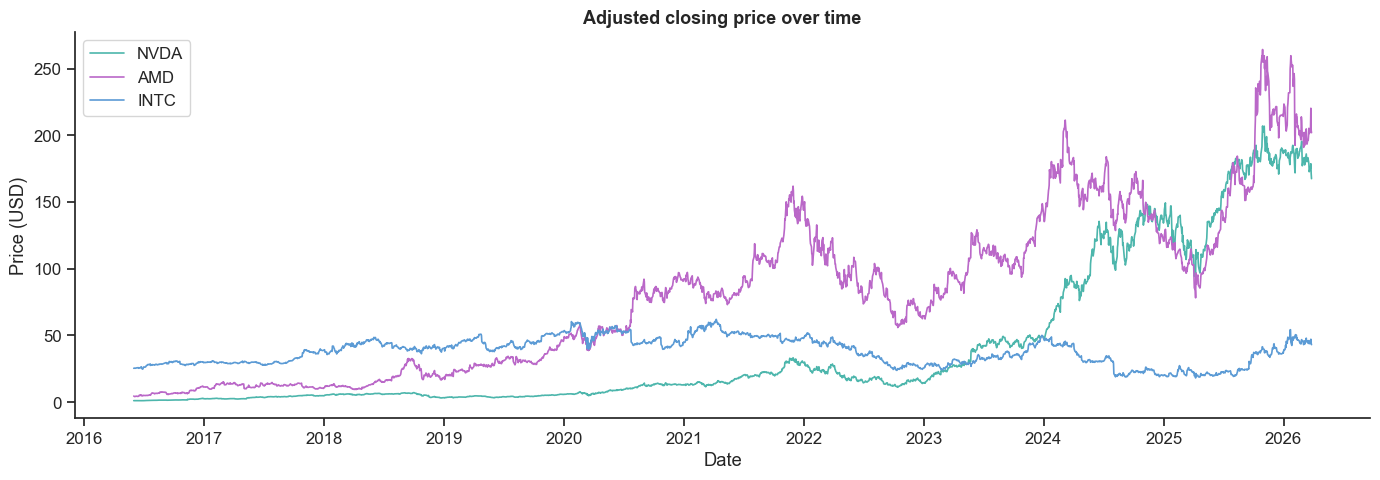

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

for ticker, color in company_colors.items():
    subset = df_final[df_final["ticker"] == ticker].copy()
    subset["date"] = pd.to_datetime(subset["date"])
    ax.plot(subset["date"], subset["adj_close"], label=ticker, color=color, linewidth=1.2)

ax.set_title("Adjusted closing price over time", fontsize=13, fontweight="bold")
ax.set_ylabel("Price (USD)")
ax.set_xlabel("Date")
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

NVIDIA and AMD show dramatically different growth trajectories compared to Intel. NVIDIA remained flat until 2023 when it surged exponentially driven by AI demand, while AMD grew steadily from 2019 with a peak in 2021–2022. Intel, by contrast, peaked around 2020–2021 and has been in a sustained decline since, reflecting its loss of competitive position in the semiconductor market.

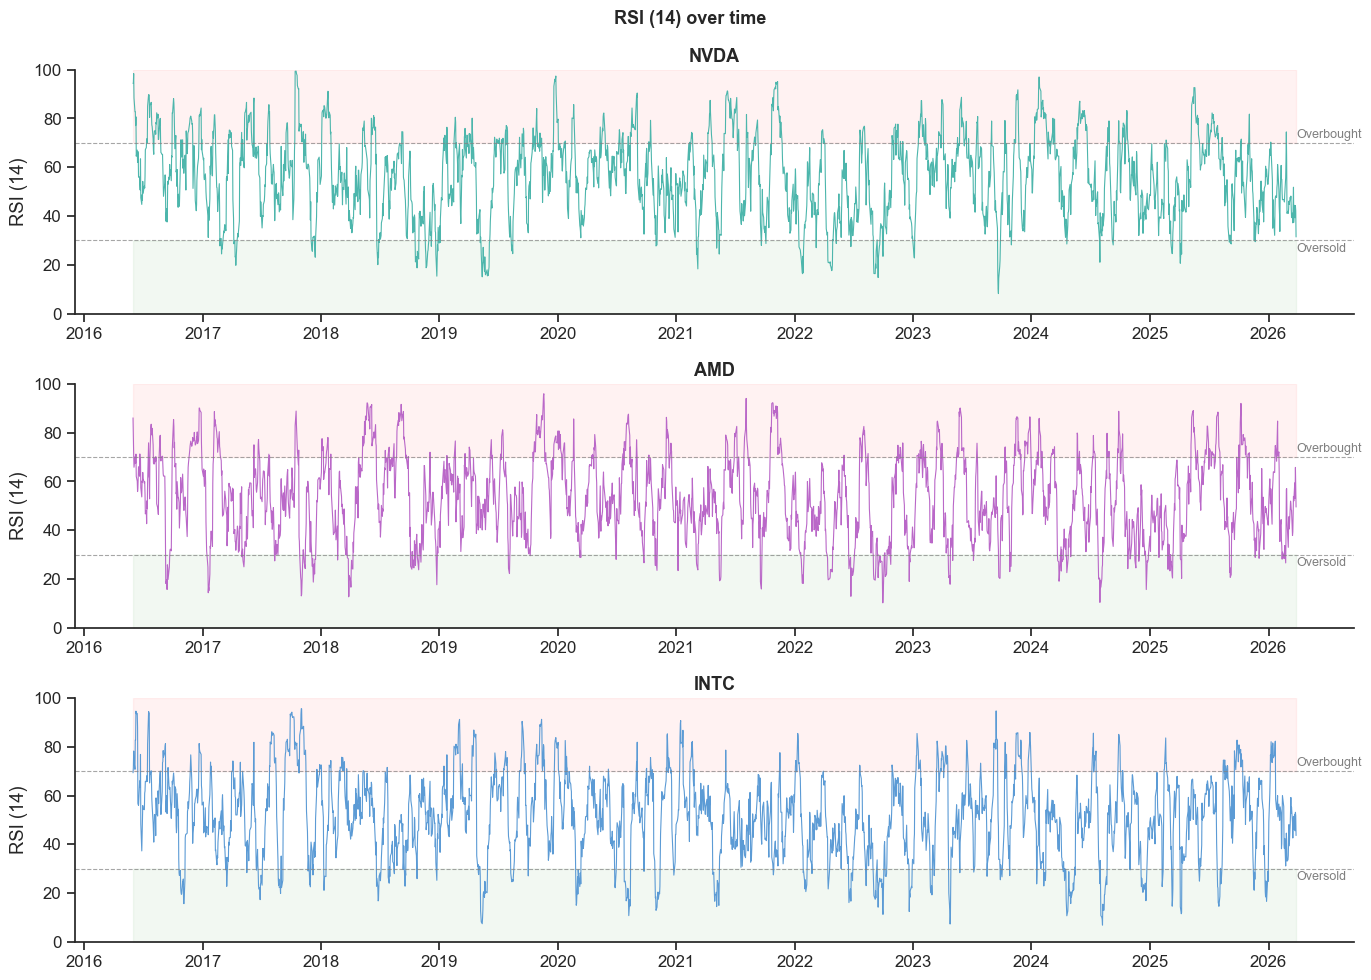

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, (ticker, color) in zip(axes, company_colors.items()):
    subset = df_final[df_final["ticker"] == ticker].copy()
    subset["date"] = pd.to_datetime(subset["date"])
    
    ax.plot(subset["date"], subset["rsi_14"], color=color, linewidth=0.8)
    ax.axhline(70, color="gray", linewidth=0.8, linestyle="--", alpha=0.7)
    ax.axhline(30, color="gray", linewidth=0.8, linestyle="--", alpha=0.7)
    ax.fill_between(subset["date"], 70, 100, alpha=0.05, color="red")
    ax.fill_between(subset["date"], 0, 30, alpha=0.05, color="green")
    ax.set_title(ticker, fontsize=13, fontweight="bold")
    ax.set_ylabel("RSI (14)")
    ax.set_ylim(0, 100)
    ax.text(subset["date"].iloc[-1], 71, "Overbought", fontsize=9, color="gray", va="bottom")
    ax.text(subset["date"].iloc[-1], 29, "Oversold", fontsize=9, color="gray", va="top")
    sns.despine(ax=ax)

fig.suptitle("RSI (14) over time", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

RSI(14) values for all three companies regularly oscillate between overbought (>70) and oversold (<30) levels, indicating recurring momentum shifts throughout the analyzed period. Most observations remain within the neutral range, suggesting that extreme market conditions are relatively short-lived.

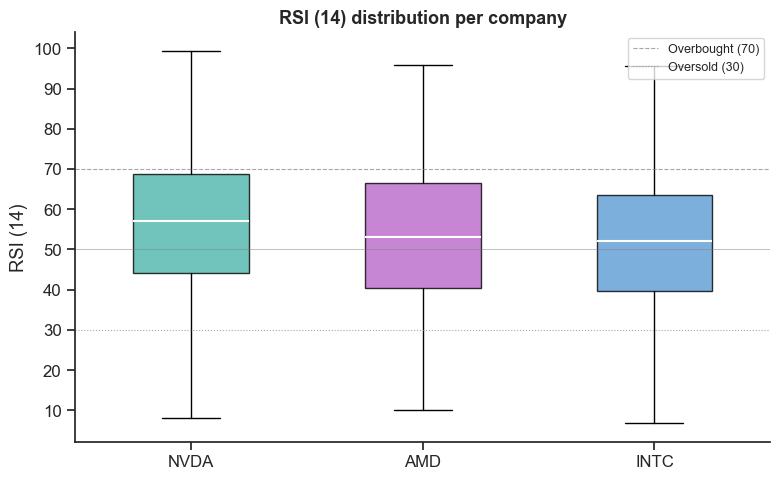

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

data = [df_final[df_final["ticker"] == ticker]["rsi_14"].dropna() 
        for ticker in ["NVDA", "AMD", "INTC"]]

bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                medianprops=dict(color="white", linewidth=1.5))

for patch, color in zip(bp["boxes"], company_colors.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.axhline(70, color="gray", linewidth=0.8, linestyle="--", alpha=0.7, label="Overbought (70)")
ax.axhline(30, color="gray", linewidth=0.8, linestyle=":",  alpha=0.7, label="Oversold (30)")
ax.axhline(50, color="gray", linewidth=0.5, alpha=0.7)
ax.set_xticks([1, 2, 3])
ax.set_yticks([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
ax.set_xticklabels(["NVDA", "AMD", "INTC"])
ax.set_ylabel("RSI (14)")
ax.set_title("RSI (14) distribution per company", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

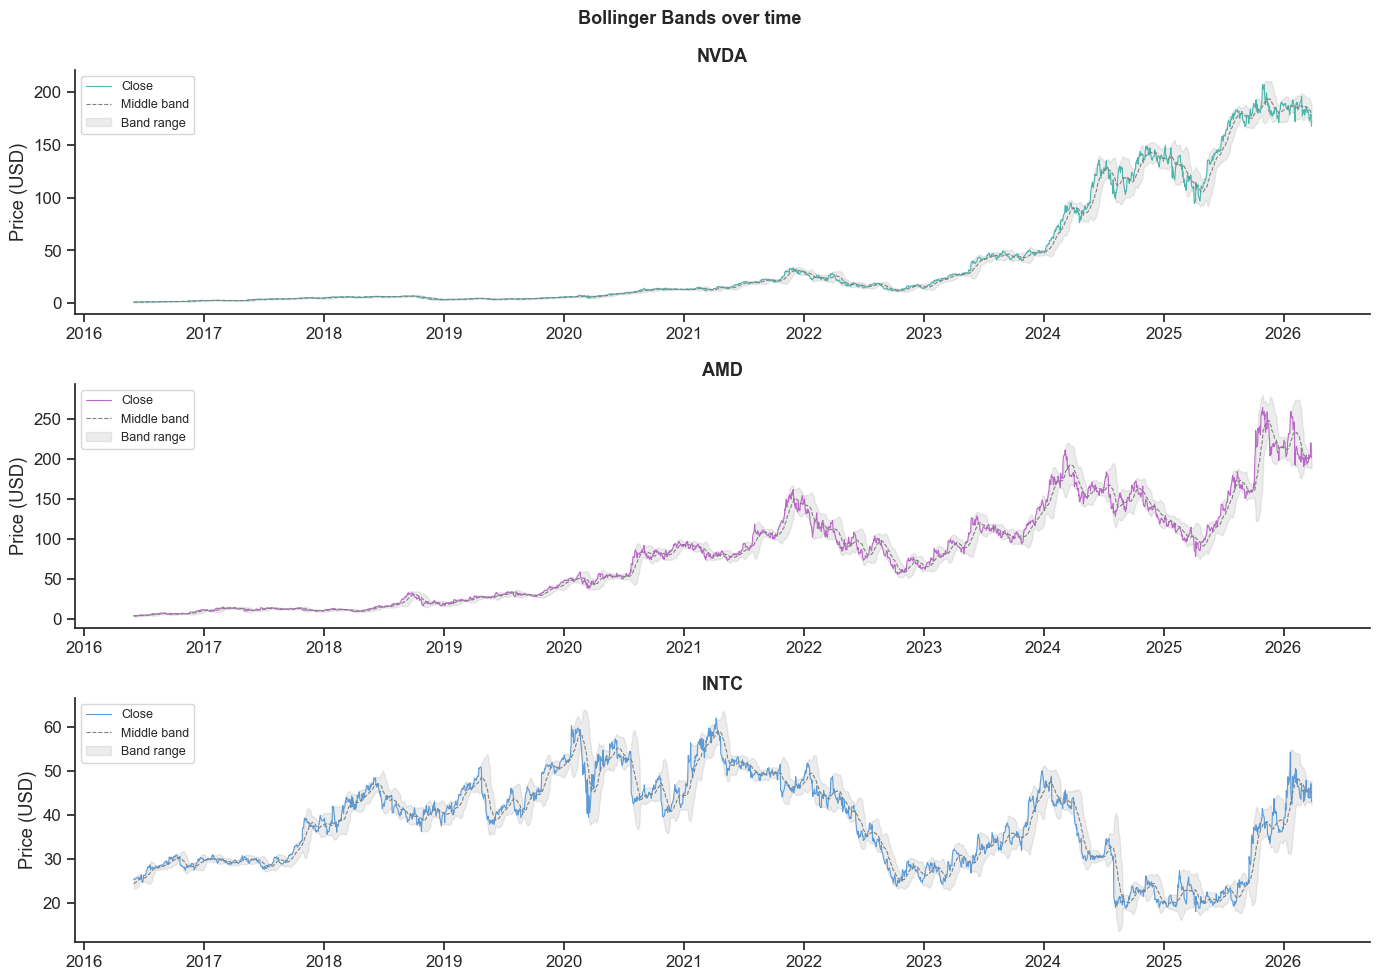

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, (ticker, color) in zip(axes, company_colors.items()):
    subset = df_final[df_final["ticker"] == ticker].copy()
    subset["date"] = pd.to_datetime(subset["date"])

    ax.plot(subset["date"], subset["adj_close"], color=color, linewidth=0.8, label="Close")
    ax.plot(subset["date"], subset["bb_middle"], color="gray", linewidth=0.8, linestyle="--", label="Middle band")
    ax.fill_between(subset["date"], subset["bb_lower"], subset["bb_upper"],
                    alpha=0.15, color="gray", label="Band range")

    ax.set_title(ticker, fontsize=13, fontweight="bold")
    ax.set_ylabel("Price (USD)")
    ax.legend(fontsize=9, loc="upper left")
    sns.despine(ax=ax)

fig.suptitle("Bollinger Bands over time", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Bollinger Bands reflect the diverging trajectories of the three companies. 
NVIDIA and AMD show narrow bands in the early period that widen significantly 
from 2023 and 2020 respectively, with price frequently touching the upper band, 
signaling strong bullish momentum. Intel, by contrast, exhibits stable band width 
throughout the entire period with no clear directional breakout, consistent with 
its prolonged sideways-to-downward price trend.

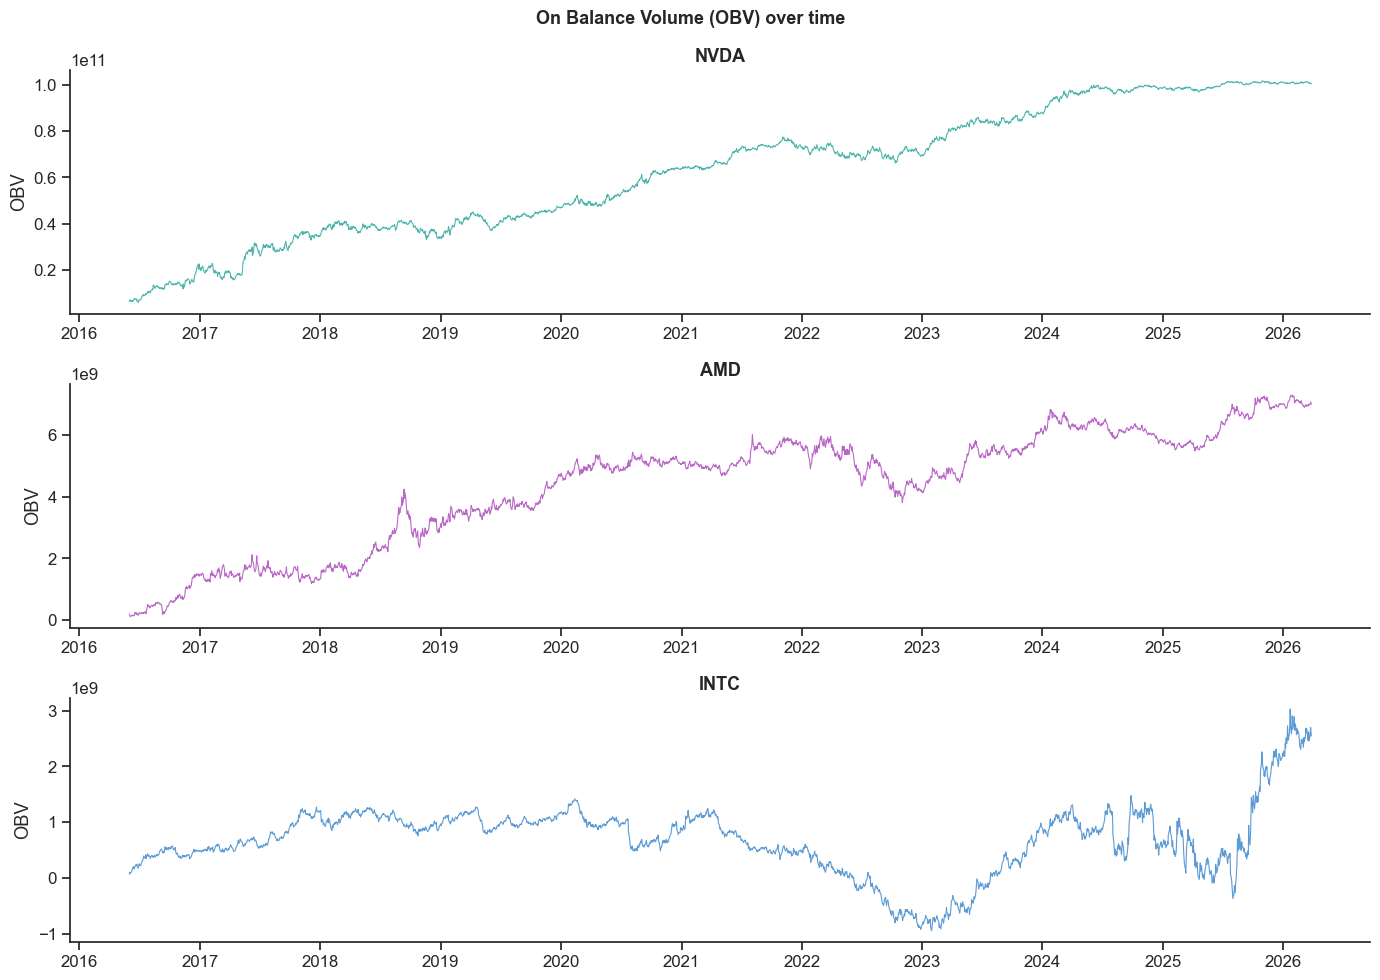

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, (ticker, color) in zip(axes, company_colors.items()):
    subset = df_final[df_final["ticker"] == ticker].copy()
    subset["date"] = pd.to_datetime(subset["date"])
    
    ax.plot(subset["date"], subset["obv"], color=color, linewidth=0.8)
    ax.set_title(ticker, fontsize=13, fontweight="bold")
    ax.set_ylabel("OBV")
    sns.despine(ax=ax)

fig.suptitle("On Balance Volume (OBV) over time", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

OBV confirms the price trends with buying pressure signals. NVIDIA shows a consistently rising OBV throughout the entire period, indicating persistent accumulation even during price stagnation before 2023, suggesting institutional buying ahead of the AI boom. AMD follows a similar upward trend with a notable acceleration from 2019. Intel's OBV tells the opposite story — after rising until 2021, it turns sharply negative through 2022–2023, indicating sustained distribution and selling pressure, before partially recovering in 2025–2026.

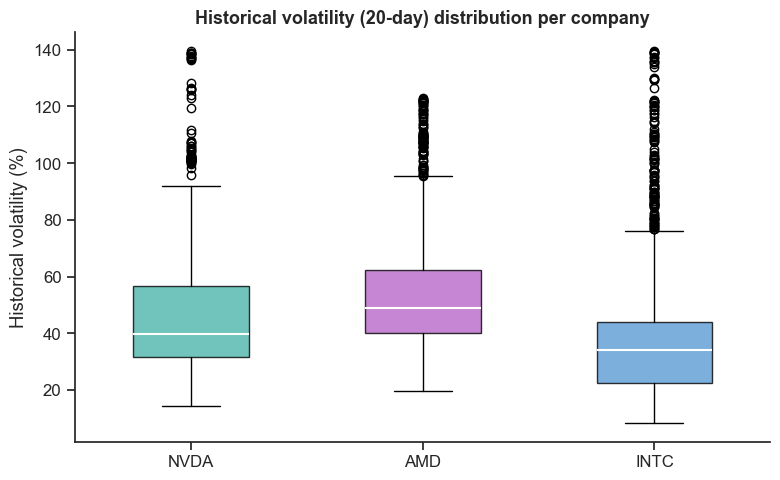

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

data = [df_final[df_final["ticker"] == ticker]["hist_vol_20"]
        for ticker in ["NVDA", "AMD", "INTC"]]

bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                medianprops=dict(color="white", linewidth=1.5))

for patch, color in zip(bp["boxes"], company_colors.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(["NVDA", "AMD", "INTC"])
ax.set_ylabel("Historical volatility (%)")
ax.set_title("Historical volatility (20-day) distribution per company",
             fontsize=13, fontweight="bold")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
for ticker in ["NVDA", "AMD", "INTC"]:
    subset = df_final[df_final["ticker"] == ticker][["date", "hist_vol_20"]].copy()
    
    Q1 = subset["hist_vol_20"].quantile(0.25)
    Q3 = subset["hist_vol_20"].quantile(0.75)
    IQR = Q3 - Q1
    threshold = Q3 + 1.5 * IQR
    
    outliers = subset[subset["hist_vol_20"] > threshold].sort_values("hist_vol_20", ascending=False)
    
    print(f"\n{ticker} — top 3 highest volatility days (outliers above {threshold:.1f}%):")
    print(outliers.head(3)[["date", "hist_vol_20"]].to_string(index=False))


NVDA — top 3 highest volatility days (outliers above 93.8%):
      date  hist_vol_20
2020-04-06   139.689610
2020-03-24   138.938466
2020-03-25   138.709174

AMD — top 3 highest volatility days (outliers above 95.5%):
      date  hist_vol_20
2017-05-22   122.797430
2017-05-17   122.745387
2017-05-19   122.615987

INTC — top 3 highest volatility days (outliers above 76.5%):
      date  hist_vol_20
2020-03-30   139.367334
2020-04-02   139.346707
2020-04-03   139.173440


AMD exhibits the highest median volatility, followed by NVIDIA and Intel. 
All three companies show outliers in the upper tail, which correspond to 
identifiable market events. For NVIDIA and Intel, 
peak volatility days cluster around March–April 2020, coinciding with the 
COVID-19 market crash. For AMD, the highest volatility days occur in May 2016, 
corresponding to the announcement of the Zen architecture.

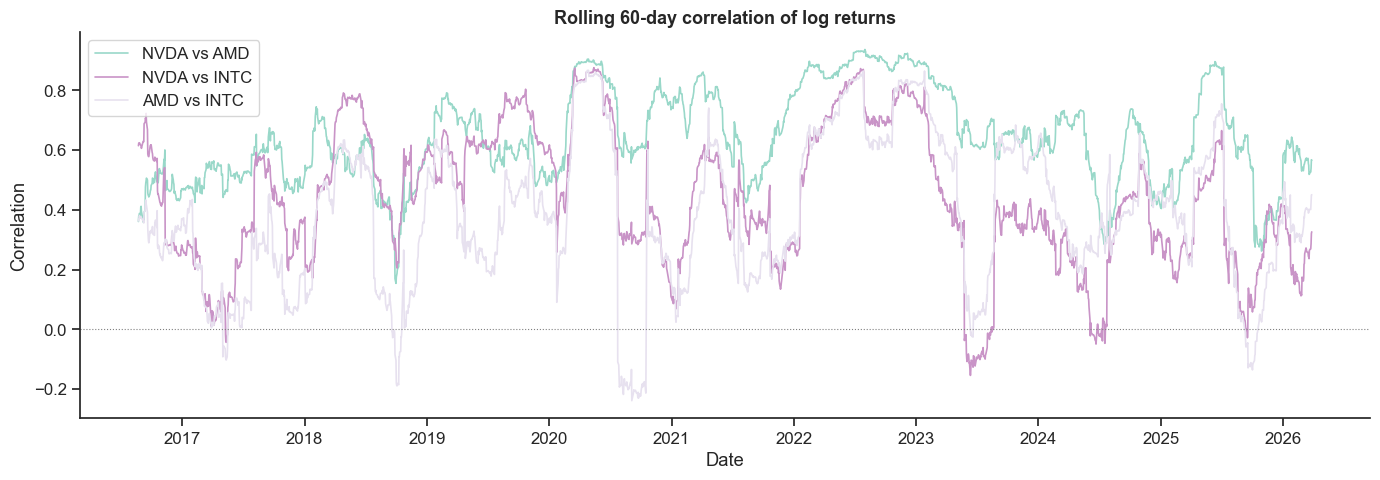

In [ ]:
returns = {}
for ticker in ["NVDA", "AMD", "INTC"]:
    subset = df_final[df_final["ticker"] == ticker][["date", "log_return"]].copy()
    subset["date"] = pd.to_datetime(subset["date"])
    returns[ticker] = subset.set_index("date")["log_return"]

returns_df = pd.DataFrame(returns)

window = 60
pairs = [("NVDA", "AMD"), ("NVDA", "INTC"), ("AMD", "INTC")]
pair_colors = ["#99d8c9", "#c994c7", "#e7e1ef"]

fig, ax = plt.subplots(figsize=(14, 5))
for (t1, t2), color in zip(pairs, pair_colors):
    rolling_corr = returns_df[t1].rolling(window).corr(returns_df[t2])
    ax.plot(returns_df.index, rolling_corr, label=f"{t1} vs {t2}", color=color, linewidth=1.2)

ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_title(f"Rolling {window}-day correlation of log returns", fontsize=13, fontweight="bold")
ax.set_ylabel("Correlation")
ax.set_xlabel("Date")
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

All pairs maintain predominantly positive correlations, confirming sector-wide co-movement. NVDA vs AMD consistently shows the highest correlation, all pairs spike during the COVID crash in 2020, and Intel's correlation with both competitors declines from 2023 onwards, reflecting its diverging business trajectory.

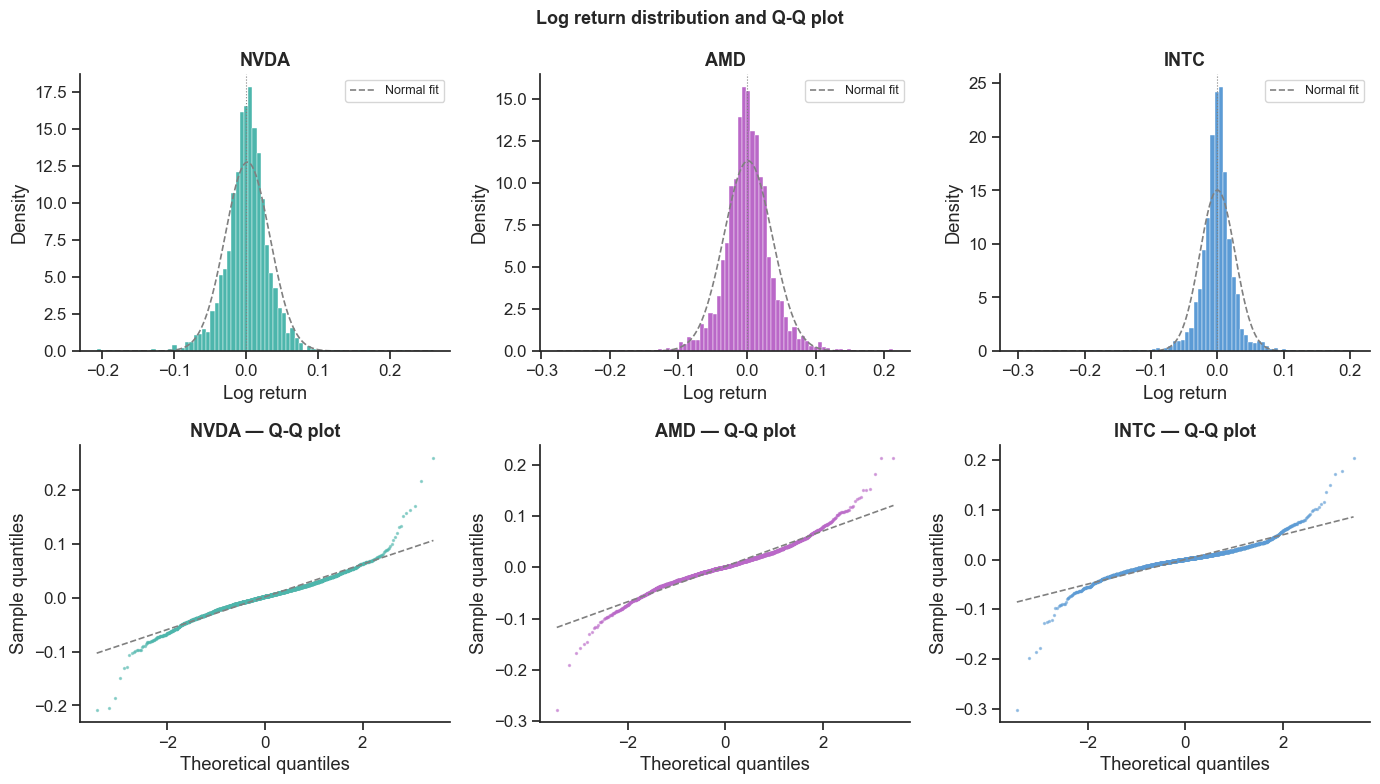

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, (ticker, color) in enumerate(company_colors.items()):
    subset = df_final[df_final["ticker"] == ticker]["log_return"].dropna()

    # Histogram
    ax = axes[0, i]
    ax.hist(subset, bins=80, color=color, edgecolor="white", linewidth=0.3, density=True)
    x = np.linspace(subset.min(), subset.max(), 200)
    ax.plot(x, stats.norm.pdf(x, subset.mean(), subset.std()),
            color="gray", linewidth=1.2, linestyle="--", label="Normal fit")
    ax.axvline(0, color="gray", linewidth=0.8, linestyle=":")
    ax.set_title(ticker, fontsize=13, fontweight="bold")
    ax.set_xlabel("Log return")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

    # QQ plot
    ax = axes[1, i]
    (osm, osr), (slope, intercept, _) = stats.probplot(subset, dist="norm")
    ax.scatter(osm, osr, color=color, s=2, alpha=0.5)
    ax.plot(osm, slope * np.array(osm) + intercept, color="gray", linewidth=1.2, linestyle="--")
    ax.set_title(f"{ticker} — Q-Q plot", fontsize=13, fontweight="bold")
    ax.set_xlabel("Theoretical quantiles")
    ax.set_ylabel("Sample quantiles")
    sns.despine(ax=ax)

fig.suptitle("Log return distribution and Q-Q plot", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Log return distributions exhibit leptokurtosis across all three companies.
The distributions are narrower and taller than the normal fit, with heavier tails, 
indicating more frequent extreme daily moves than a normal distribution would predict. 
This is confirmed by the Q-Q plots, where sample quantiles deviate from the theoretical 
line at both ends in an S-shape. This is a well-known property of financial returns 
and suggests that models assuming normality may underperform.

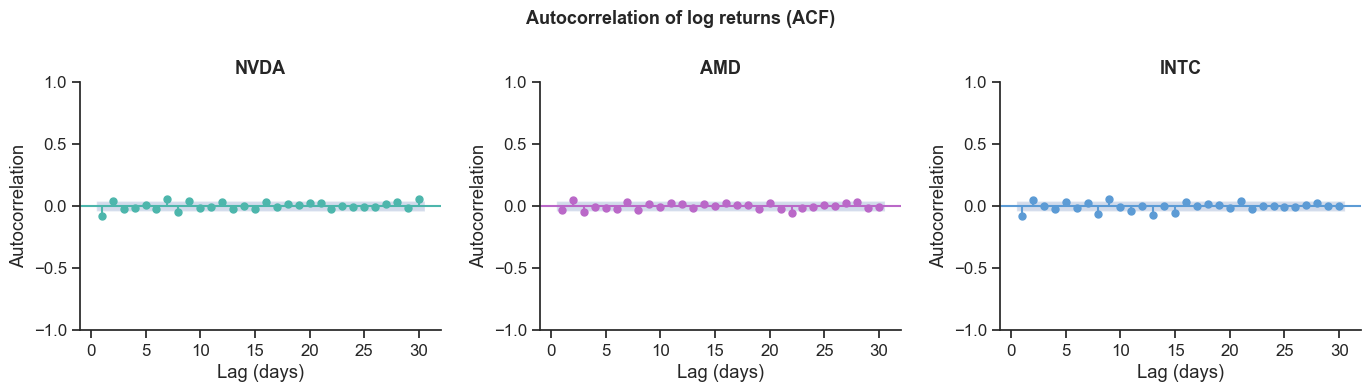

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (ticker, color) in zip(axes, company_colors.items()):
    subset = df_final[df_final["ticker"] == ticker]["log_return"].dropna()
    plot_acf(subset, ax=ax, lags=30, color=color, vlines_kwargs={"colors": color},
             alpha=0.05, zero=False)
    ax.set_title(ticker, fontsize=13, fontweight="bold")
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Autocorrelation")
    sns.despine(ax=ax)

fig.suptitle("Autocorrelation of log returns (ACF)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

The ACF plots show near-zero autocorrelation at all lags for all three companies, 
indicating no linear dependence between consecutive log returns. This is consistent 
with the Efficient Market Hypothesis and confirms that past returns alone carry 
little predictive signal, motivating the inclusion of technical indicators, 
macroeconomic features, and sentiment data as additional sources of information.

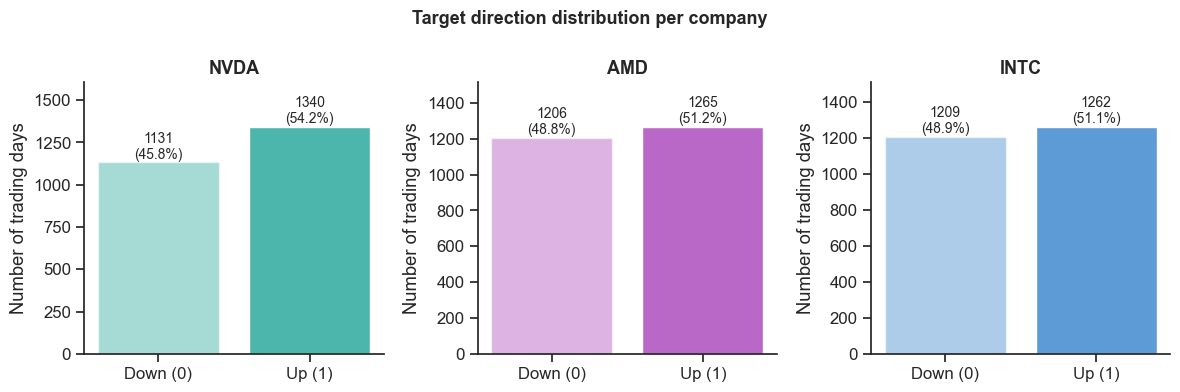

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (ticker, color) in zip(axes, company_colors.items()):
    subset = df_final[df_final["ticker"] == ticker]
    counts = subset["target_direction"].value_counts().sort_index()

    bars = ax.bar(["Down (0)", "Up (1)"], counts.values,
                  color=[color, color], edgecolor="white")
    bars[0].set_alpha(0.5)
    bars[1].set_alpha(1.0)

    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                f"{val}\n({100 * val / len(subset):.1f}%)",
                ha="center", va="bottom", fontsize=10)

    ax.set_title(ticker, fontsize=13, fontweight="bold")
    ax.set_ylabel("Number of trading days")
    ax.set_ylim(0, counts.max() * 1.2)
    sns.despine(ax=ax)

fig.suptitle("Target direction distribution per company", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Target direction** is approximately balanced across all three companies. NVIDIA shows 
a slight upward bias (54.4% Up vs. 45.6% Down), while AMD and Intel are nearly 
perfectly balanced at 51.2% vs. 48.8%. This balance is expected and reflects a 
well-known property of stock markets over long horizons, prices tend to rise slightly 
more often than they fall, consistent with the long-term positive equity premium. 
The near-perfect balance means that no class weighting or resampling techniques 
are required for classification modeling.

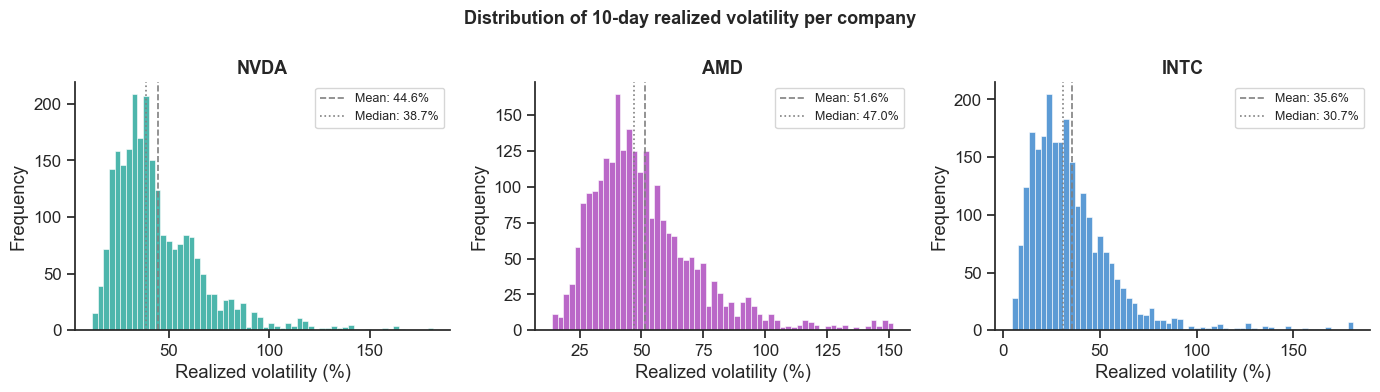

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (ticker, color) in zip(axes, company_colors.items()):
    subset = df_final[df_final["ticker"] == ticker]["target_volatility_10d"].dropna()
    ax.hist(subset, bins=60, color=color, edgecolor="white", linewidth=0.4)
    ax.axvline(subset.mean(), color="gray", linewidth=1.2, linestyle="--",
               label=f"Mean: {subset.mean():.1f}%")
    ax.axvline(subset.median(), color="gray", linewidth=1.2, linestyle=":",
               label=f"Median: {subset.median():.1f}%")
    ax.set_title(ticker, fontsize=13, fontweight="bold")
    ax.set_xlabel("Realized volatility (%)")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

fig.suptitle("Distribution of 10-day realized volatility per company",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Target volatility** distributions are right-skewed for all three companies, 
which is typical for realized volatility measures — calm periods dominate, 
while occasional spikes (earnings, macro shocks, COVID-19) pull the tail rightward. 
AMD exhibits the highest average volatility (mean 51.5%, median 46.9%), followed by 
NVIDIA (mean 44.6%, median 38.6%) and Intel (mean 35.4%, median 30.6%). 
The gap between mean and median in all three cases confirms the presence of outliers 
corresponding to periods of extreme market stress.

If outliers prove problematic for a specific model, potential approaches include 
log transformation of the target variable or winsorization. This will be addressed 
at the feature engineering stage, depending on the choice of model.

## 7. Final Dataset

The final dataset contains daily market data, technical indicators, and prediction targets for NVIDIA, AMD, and Intel. Rows containing missing values generated by rolling-window calculations and future volatility target construction were removed

In [22]:
OUTPUT_PATH = f"{OUTPUT_DIR}/yahoo_finance.csv"

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("yahoo_finance")

with mlflow.start_run(run_name="yahoo_finance_download"):

    mlflow.log_param("tickers",    ", ".join(TICKERS))
    mlflow.log_param("start_date", START_DATE)
    mlflow.log_param("end_date",   END_DATE)
    mlflow.log_param("n_features", len(df_final.columns))
    mlflow.log_metric("total_rows", len(df_final))
    mlflow.log_param("volatility_horizon_days", 10)

    for ticker in TICKERS:
        subset = df_final[df_final["ticker"] == ticker]

        mlflow.log_metric(f"rows_{ticker}", len(subset))
        mlflow.log_metric(
            f"direction_positive_{ticker}",
            subset["target_direction"].sum()
        )
        mlflow.log_metric(
            f"direction_negative_{ticker}",
            (subset["target_direction"] == 0).sum()
        )
        mlflow.log_metric(
            f"volatility_mean_{ticker}",
            subset["target_volatility_10d"].mean()
        )
        mlflow.log_metric(
            f"volatility_std_{ticker}",
            subset["target_volatility_10d"].std()
        )

    df_final.to_csv(OUTPUT_PATH, index=False)

    print(f"Dataset saved : {OUTPUT_PATH}")
    print("MLflow run    : completed")

Dataset saved : datasets/processed/yahoo_finance.csv
MLflow run    : completed
